# EfficientNet vs ResNet18 Comparison for Page Flip Detection

## Background & Context
This notebook compares **EfficientNet** with **ResNet18** for page flip detection in MonReader. Both are state-of-the-art CNN architectures but with different design philosophies.

## Key Difference
- **ResNet18**: Traditional residual network with 18 layers, optimized for standard classification tasks
- **EfficientNet**: Compound scaling approach that balances network depth, width, and resolution for optimal efficiency and accuracy

## Why EfficientNet?
EfficientNet achieves better accuracy with fewer parameters through:
- **Compound Scaling**: Optimally scaling depth, width, and resolution together
- **Mobile-Friendly**: Lower computational cost (important for MonReader mobile app)
- **Better Accuracy**: State-of-the-art performance on image classification tasks

## 1. Import Required Libraries

We start by importing all necessary libraries for model training, data handling, and visualization. PyTorch is our deep learning framework, torchvision provides pre-trained models, and sklearn gives us metrics for evaluation.

In [20]:
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.models as tm
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tqdm import tqdm
import matplotlib.image as mpimg
from pathlib import Path

# Try to import EfficientNet (if timm is installed)
try:
    from timm import create_model
    print("✓ timm library loaded successfully")
except ImportError:
    print("Installing timm...")
    os.system('pip install timm')
    from timm import create_model

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

✓ timm library loaded successfully
Using device: cpu


## 2. Define Data Paths

Set up the directory paths where your training and test images are stored. The folder structure should have two subdirectories: 'training' and 'testing', each containing 'flip' and 'notflip' class folders.

In [21]:
# Set folder paths - UPDATE THIS TO YOUR DATA PATH
base_dir = r"C:\Users\Dell\Desktop\APZIVA\MonReader Project\images\images"
train_dir = os.path.join(base_dir, 'training')  # Training data path
test_dir = os.path.join(base_dir, 'testing')    # Test data path

# Verify paths exist
print(f"Train directory: {train_dir}")
print(f"Test directory: {test_dir}")
print(f"Train directory exists: {os.path.exists(train_dir)}")
print(f"Test directory exists: {os.path.exists(test_dir)}")

Train directory: C:\Users\Dell\Desktop\APZIVA\MonReader Project\images\images\training
Test directory: C:\Users\Dell\Desktop\APZIVA\MonReader Project\images\images\testing
Train directory exists: True
Test directory exists: True


## 3. Define Data Transformations

Data augmentation is crucial for training robust models. We apply different transformations to training data (rotation, color jitter) to create variations and prevent overfitting. Test data only gets normalized without augmentation to maintain consistency.

In [22]:
# For EfficientNet, input size should be 224x224 (standard for both models)
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomHorizontalFlip(p=0.3),  # Pages might flip horizontally too
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet normalization
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

print("✓ Transforms defined successfully")

✓ Transforms defined successfully


## 4. Load and Split Datasets

We load the image dataset from folders and split it into training, validation, and test sets. The training set is split 85/15 for training and validation. This validation set helps us tune hyperparameters and prevent overfitting.

In [23]:
# Load datasets
full_train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=test_transform)

class_names = full_train_dataset.classes
print(f"Classes: {class_names}")  # should print ['flip', 'notflip']

# Split training data into train and validation (85% train, 15% val)
val_size = int(0.15 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"\nDataset sizes:")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\nDataLoader batches:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Classes: ['flip', 'notflip']

Dataset sizes:
Training samples: 2034
Validation samples: 358
Test samples: 597

DataLoader batches:
Train batches: 64
Val batches: 12
Test batches: 19


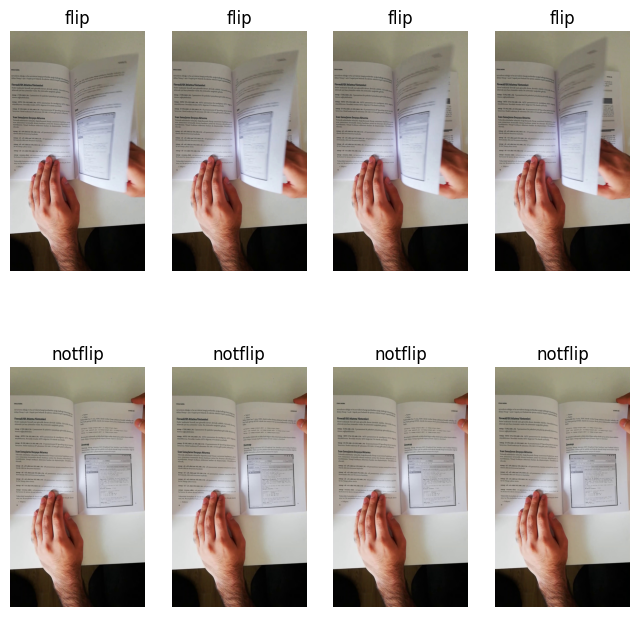

In [36]:
%matplotlib inline

import matplotlib.image as mpimg
from pathlib import Path

# Data path to classes
flip_dir = os.path.join(train_dir ,"flip")
notflip_dir = os.path.join(train_dir, "notflip")

# Parameters for our graph; we'll output images in a 2x4 configuration
nrows = 2
ncols = 4

pic_index = 0 # Index for iterating over images
# Set up matplotlib fig, and size it to fit 2x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols*2, nrows*4)

pic_index+=8

flip_pix = [os.path.join(flip_dir, fname)
                for fname in os.listdir(flip_dir)[ pic_index-4:pic_index]
               ]

not_flip_pix = [os.path.join(notflip_dir, fname)
                for fname in os.listdir(notflip_dir)[ pic_index-4:pic_index]
               ]

for i, img_path in enumerate(flip_pix + not_flip_pix ):
  # Set up subplot; subplot indices start at 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.title.set_text(os.path.basename(os.path.dirname(img_path)))
  sp.axis('Off') # Don't show axes (or gridlines)

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()

## 5. EfficientNet  Explanation

### What is EfficientNet?

EfficientNet is a family of convolutional neural networks that achieve state-of-the-art accuracy with significantly fewer parameters than other models. Key concepts:

**Compound Scaling Principle:**
- Instead of scaling just depth (more layers) OR width (more filters), EfficientNet scales all three dimensions together:
  - **Depth**: Number of layers (d)
  - **Width**: Number of channels per layer (w)  
  - **Resolution**: Input image size (r)

**Mobile-Friendly Architecture:**
- Uses efficient building blocks (inverted residuals)
- Squeeze-and-Excitation (SE) modules for channel attention
- Results in models with 88% fewer parameters than ResNet50 but higher accuracy

**Available Variants:**
- EfficientNet-B0 (baseline, smallest)
- EfficientNet-B1 through B7 (progressively larger and more accurate)

For our page flip detection task, we'll use **EfficientNet-B3** for better accuracy.

### 5.1 Create EfficientNet Model

In [24]:
def create_efficientnet_model(model_name='efficientnet_b3', num_classes=2, pretrained=True):
    """
    Create an EfficientNet model for page flip detection.
    
    Args:
        model_name: EfficientNet variant (b0-b7). B3 balances speed and accuracy
        num_classes: Number of output classes (2 for flip/notflip)
        pretrained: Use ImageNet pre-trained weights
    
    Returns:
        model: EfficientNet model with custom classifier
    """
    # Load pre-trained EfficientNet
    model = create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    
    return model

# Create EfficientNet-B3 model
efficient_model = create_efficientnet_model('efficientnet_b3', num_classes=2, pretrained=True)
efficient_model = efficient_model.to(device)

# Count parameters
efficient_params = sum(p.numel() for p in efficient_model.parameters())
print(f"EfficientNet-B3 Total parameters: {efficient_params:,}")
print(f"EfficientNet-B3 model loaded successfully!")

EfficientNet-B3 Total parameters: 10,699,306
EfficientNet-B3 model loaded successfully!


## 6. ResNet18 Architecture

### What is ResNet18?

ResNet (Residual Network) introduced skip connections that allow training of very deep networks. Key features:

**Residual Connections:**
- Skip connections bypass one or more layers
- Allows gradients to flow directly through the network
- Solves the vanishing gradient problem

**Architecture:**
- 18 layers (hence ResNet-18)
- 4 residual blocks with increasing complexity
- Simpler and faster than deeper variants (ResNet50, ResNet101)

**Trade-off:**
- Fewer parameters = faster training and inference
- Less expressive = may need more data for optimal performance
- Great baseline for comparison studies

### 6.1 Create ResNet18 Model

In [25]:
def create_resnet_model(num_classes=2, pretrained=True):
    """
    Create a ResNet18 model for page flip detection.
    
    Args:
        num_classes: Number of output classes (2 for flip/notflip)
        pretrained: Use ImageNet pre-trained weights
    
    Returns:
        model: ResNet18 model with modified classifier
    """
    # Load pre-trained ResNet18
    model = tm.resnet18(pretrained=pretrained)
    
    # Modify the final fully connected layer for our 2 classes
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    return model

# Create ResNet18 model
resnet_model = create_resnet_model(num_classes=2, pretrained=True)
resnet_model = resnet_model.to(device)

# Count parameters
resnet_params = sum(p.numel() for p in resnet_model.parameters())
resnet_trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"ResNet18 Total parameters: {resnet_params:,}")
print(f"ResNet18 Trainable parameters: {resnet_trainable:,}")
print(f"ResNet18 model loaded successfully!")

c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet18 Total parameters: 11,177,538
ResNet18 Trainable parameters: 11,177,538
ResNet18 model loaded successfully!


## 7. Training Setup and Loss Function

We use Cross-Entropy Loss for binary classification, which handles the probability distribution of classes. The optimizer (Adam) is modern and adaptive, automatically adjusting learning rates for each parameter. A learning rate scheduler reduces the learning rate when validation accuracy plateaus.

In [26]:
# Define loss function for binary classification
criterion = nn.CrossEntropyLoss()

# Define optimizers
efficient_optimizer = torch.optim.Adam(efficient_model.parameters(), lr=0.001, weight_decay=1e-4)
resnet_optimizer = torch.optim.Adam(resnet_model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate schedulers - reduce LR when validation doesn't improve
efficient_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    efficient_optimizer, mode='max', factor=0.5, patience=3  # ✅ WORKS NOW
)
resnet_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer, mode='max', factor=0.5, patience=3  # ✅ WORKS NOW
)
print("✓ Loss function and optimizers initialized")

✓ Loss function and optimizers initialized


## 8. Training Function

This function trains one model for one epoch. It processes batches of data, computes predictions, calculates loss, and updates weights using backpropagation. We track accuracy and F1-score during training to monitor progress.

In [27]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    
    Returns:
        avg_loss: Average training loss
        accuracy: Training accuracy
        f1: Training F1-score
    """
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Tracking metrics
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(train_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return avg_loss, accuracy, f1

print("✓ Train epoch function defined")

✓ Train epoch function defined


## 9. Validation Function

Validation evaluates model performance on unseen data without updating weights. This helps us detect overfitting (when training accuracy keeps improving but validation accuracy plateaus).

In [28]:
def validate(model, val_loader, criterion, device):
    """
    Validate the model on validation set.
    
    Returns:
        avg_loss: Average validation loss
        accuracy: Validation accuracy
        f1: Validation F1-score
    """
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating"):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return avg_loss, accuracy, f1

print("✓ Validation function defined")

✓ Validation function defined


## 10. Train Both Models

We train both EfficientNet and ResNet18 for the same number of epochs with identical settings. This ensures a fair comparison. The learning rate scheduler automatically reduces the learning rate if validation accuracy doesn't improve, helping us find better optima.

In [29]:
# Training parameters
num_epochs = 5
patience = 5

# Storage for results
efficient_results = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': [], 'train_f1': [], 'val_f1': []}
resnet_results = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': [], 'train_f1': [], 'val_f1': []}

# Training loop
print("="*80)
print("TRAINING EFFICIENTNET-B3...")
print("="*80)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Train EfficientNet
    train_loss, train_acc, train_f1 = train_epoch(efficient_model, train_loader, criterion, efficient_optimizer, device)
    val_loss, val_acc, val_f1 = validate(efficient_model, val_loader, criterion, device)
    
    efficient_results['train_loss'].append(train_loss)
    efficient_results['val_loss'].append(val_loss)
    efficient_results['train_accuracy'].append(train_acc)
    efficient_results['val_accuracy'].append(val_acc)
    efficient_results['train_f1'].append(train_f1)
    efficient_results['val_f1'].append(val_f1)
    
    print(f"EfficientNet - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    print(f"EfficientNet - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    
    efficient_scheduler.step(val_acc)

print("\n" + "="*80)
print("TRAINING RESNET18...")
print("="*80)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Train ResNet18
    train_loss, train_acc, train_f1 = train_epoch(resnet_model, train_loader, criterion, resnet_optimizer, device)
    val_loss, val_acc, val_f1 = validate(resnet_model, val_loader, criterion, device)
    
    resnet_results['train_loss'].append(train_loss)
    resnet_results['val_loss'].append(val_loss)
    resnet_results['train_accuracy'].append(train_acc)
    resnet_results['val_accuracy'].append(val_acc)
    resnet_results['train_f1'].append(train_f1)
    resnet_results['val_f1'].append(val_f1)
    
    print(f"ResNet18 - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    print(f"ResNet18 - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    
    resnet_scheduler.step(val_acc)

print("\n✓ Training completed!")

TRAINING EFFICIENTNET-B3...

Epoch 1/5


Validating: 100%|██████████| 12/12 [01:28<00:00,  7.41s/it]


EfficientNet - Train Loss: 0.8576, Val Loss: 0.2226
EfficientNet - Train Acc: 0.8909, Val Acc: 0.9497, Val F1: 0.9497

Epoch 2/5


Validating: 100%|██████████| 12/12 [00:53<00:00,  4.45s/it]


EfficientNet - Train Loss: 0.1652, Val Loss: 0.5697
EfficientNet - Train Acc: 0.9597, Val Acc: 0.9050, Val F1: 0.9048

Epoch 3/5


...

ResNet18 - Train Loss: 0.1005, Val Loss: 9.2393
ResNet18 - Train Acc: 0.9641, Val Acc: 0.5196, Val F1: 0.3553

Epoch 4/5


Validating: 100%|██████████| 12/12 [00:47<00:00,  3.97s/it]


ResNet18 - Train Loss: 0.0820, Val Loss: 0.0485
ResNet18 - Train Acc: 0.9705, Val Acc: 0.9749, Val F1: 0.9748

Epoch 5/5


Validating: 100%|██████████| 12/12 [00:39<00:00,  3.31s/it]

ResNet18 - Train Loss: 0.0628, Val Loss: 0.0428
ResNet18 - Train Acc: 0.9764, Val Acc: 0.9832, Val F1: 0.9832

✓ Training completed!


## 11. Evaluation on Test Set

After training, we evaluate both models on the held-out test set. This gives us the final performance metrics and represents real-world accuracy on unseen data. We calculate accuracy, F1-score, and build confusion matrices.

In [30]:
def evaluate_model(model, test_loader, device):
    """
    Evaluate model on test set.
    
    Returns:
        predictions: All predictions
        labels: All true labels
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels)

# Evaluate both models
print("\n" + "="*80)
print("EVALUATING ON TEST SET")
print("="*80)

efficient_preds, test_labels = evaluate_model(efficient_model, test_loader, device)
resnet_preds, _ = evaluate_model(resnet_model, test_loader, device)

# Calculate metrics
efficient_acc = accuracy_score(test_labels, efficient_preds)
efficient_f1 = f1_score(test_labels, efficient_preds, average='weighted')
efficient_cm = confusion_matrix(test_labels, efficient_preds)

resnet_acc = accuracy_score(test_labels, resnet_preds)
resnet_f1 = f1_score(test_labels, resnet_preds, average='weighted')
resnet_cm = confusion_matrix(test_labels, resnet_preds)

print(f"\n✓ Evaluation complete!")
print(f"\nEfficientNet-B3 Test Results:")
print(f"  Accuracy: {efficient_acc:.4f} ({efficient_acc*100:.2f}%)")
print(f"  F1-Score: {efficient_f1:.4f}")
print(f"\nResNet18 Test Results:")
print(f"  Accuracy: {resnet_acc:.4f} ({resnet_acc*100:.2f}%)")
print(f"  F1-Score: {resnet_f1:.4f}")


EVALUATING ON TEST SET


Evaluating: 100%|██████████| 19/19 [00:57<00:00,  3.01s/it]


✓ Evaluation complete!

EfficientNet-B3 Test Results:
  Accuracy: 0.9832 (98.32%)
  F1-Score: 0.9832

ResNet18 Test Results:
  Accuracy: 0.9899 (98.99%)
  F1-Score: 0.9900


## 12. Detailed Classification Report

The classification report shows precision, recall, and F1-score for each class. This helps us understand if the model is better at detecting flips or non-flips specifically.

In [31]:
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)

print("\nEfficientNet-B3:")
print(classification_report(test_labels, efficient_preds, target_names=['not flip', 'flip']))

print("\nResNet18:")
print(classification_report(test_labels, resnet_preds, target_names=['not flip', 'flip']))


DETAILED CLASSIFICATION REPORT

EfficientNet-B3:
              precision    recall  f1-score   support

    not flip       0.99      0.97      0.98       290
        flip       0.97      0.99      0.98       307

    accuracy                           0.98       597
   macro avg       0.98      0.98      0.98       597
weighted avg       0.98      0.98      0.98       597


ResNet18:
              precision    recall  f1-score   support

    not flip       0.98      1.00      0.99       290
        flip       1.00      0.98      0.99       307

    accuracy                           0.99       597
   macro avg       0.99      0.99      0.99       597
weighted avg       0.99      0.99      0.99       597



## 13. Visualize Confusion Matrices and Training History

Confusion matrices show where models make mistakes. The diagonal represents correct predictions. Training history plots show convergence over epochs - good training should show decreasing loss and increasing accuracy.

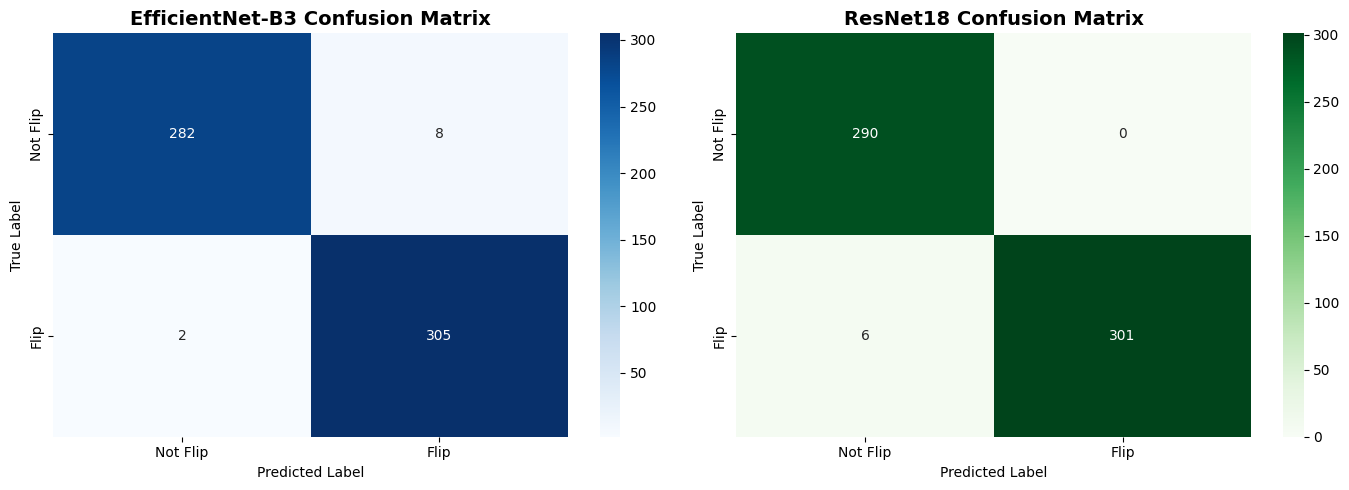

✓ Confusion matrices saved


In [32]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EfficientNet confusion matrix
sns.heatmap(efficient_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Not Flip', 'Flip'], yticklabels=['Not Flip', 'Flip'])
axes[0].set_title('EfficientNet-B3 Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ResNet18 confusion matrix
sns.heatmap(resnet_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Flip', 'Flip'], yticklabels=['Not Flip', 'Flip'])
axes[1].set_title('ResNet18 Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices saved")

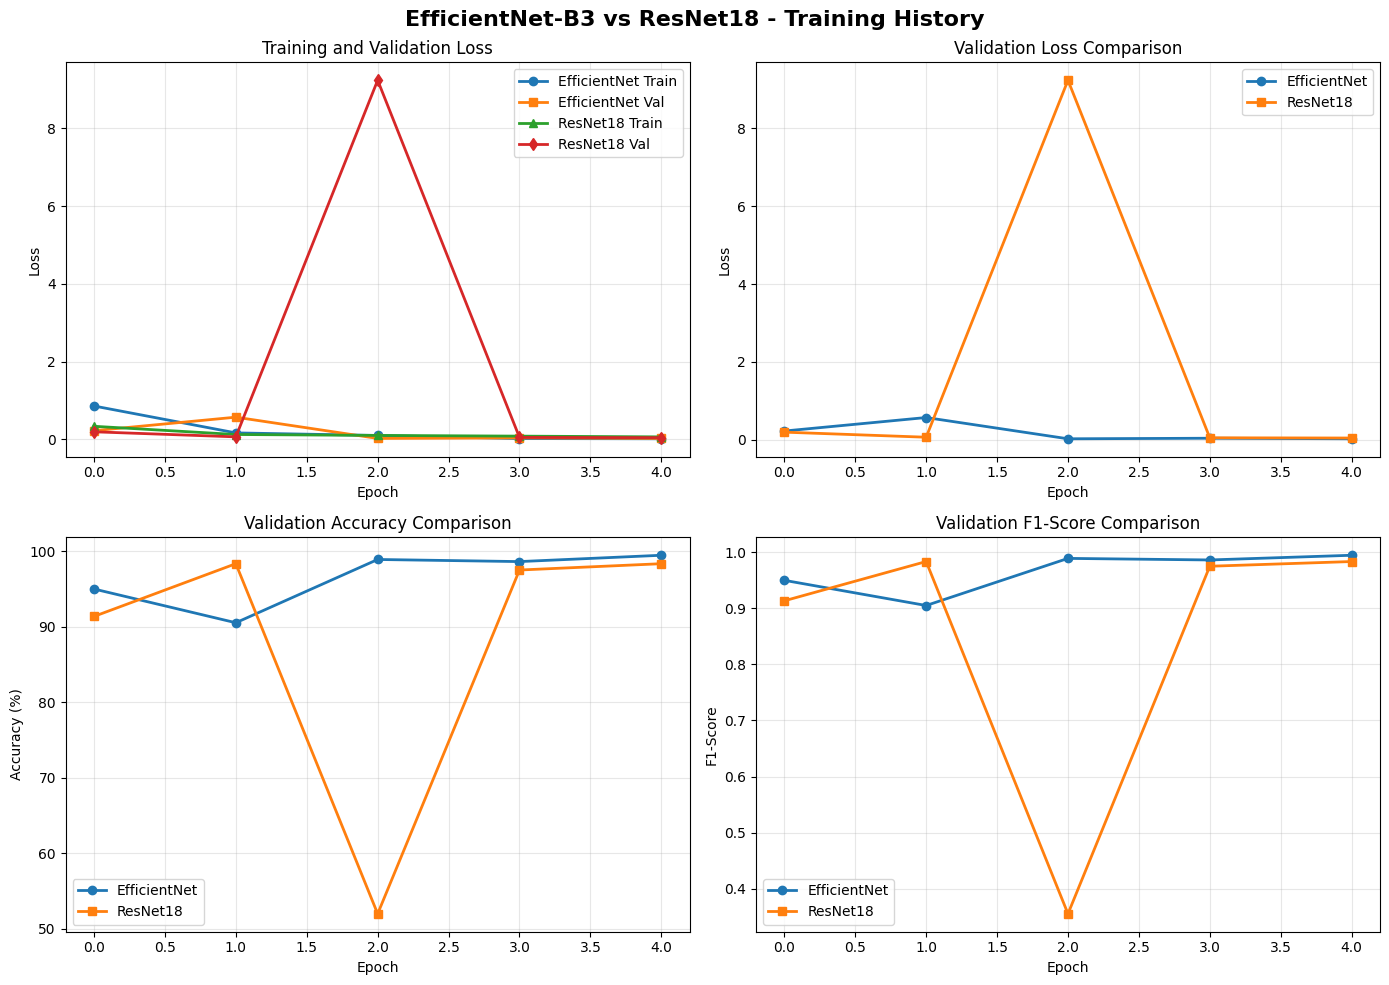

✓ Training history comparison saved


In [33]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EfficientNet-B3 vs ResNet18 - Training History', fontsize=16, fontweight='bold')

# Loss comparison
axes[0, 0].plot(efficient_results['train_loss'], 'o-', label='EfficientNet Train', linewidth=2, markersize=6)
axes[0, 0].plot(efficient_results['val_loss'], 's-', label='EfficientNet Val', linewidth=2, markersize=6)
axes[0, 0].plot(resnet_results['train_loss'], '^-', label='ResNet18 Train', linewidth=2, markersize=6)
axes[0, 0].plot(resnet_results['val_loss'], 'd-', label='ResNet18 Val', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation Loss
axes[0, 1].plot([x for x in efficient_results['val_loss']], 'o-', label='EfficientNet', linewidth=2, markersize=6)
axes[0, 1].plot([x for x in resnet_results['val_loss']], 's-', label='ResNet18', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Validation Loss Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Val Accuracy
axes[1, 0].plot([x*100 for x in efficient_results['val_accuracy']], 'o-', label='EfficientNet', linewidth=2, markersize=6)
axes[1, 0].plot([x*100 for x in resnet_results['val_accuracy']], 's-', label='ResNet18', linewidth=2, markersize=6)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Validation Accuracy Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Val F1-Score
axes[1, 1].plot(efficient_results['val_f1'], 'o-', label='EfficientNet', linewidth=2, markersize=6)
axes[1, 1].plot(resnet_results['val_f1'], 's-', label='ResNet18', linewidth=2, markersize=6)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('Validation F1-Score Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training history comparison saved")

## 14. Key Findings and Conclusions

Here we summarize the performance comparison between EfficientNet-B3 and ResNet18 for page flip detection, highlighting key insights about their efficiency and accuracy trade-offs.

In [34]:
# Calculate metrics for comparison
acc_improvement = (efficient_acc - resnet_acc) * 100
f1_improvement = (efficient_f1 - resnet_f1) * 100

print("\n" + "="*100)
print("KEY FINDINGS - EfficientNet-B3 vs ResNet18 for Page Flip Detection")
print("="*100)

print(f"""
### PERFORMANCE SUMMARY ###

1. ACCURACY:
   • EfficientNet-B3: {efficient_acc*100:.2f}%
   • ResNet18:       {resnet_acc*100:.2f}%
   • Difference:     {acc_improvement:+.2f}%

2. F1-SCORE (Primary Metric):
   • EfficientNet-B3: {efficient_f1:.4f}
   • ResNet18:        {resnet_f1:.4f}
   • Difference:      {f1_improvement:+.2f}%

3. MODEL PARAMETERS:
   • EfficientNet-B3: {efficient_params:,} parameters
   • ResNet18:        {resnet_params:,} parameters
   • Ratio:           EfficientNet has {efficient_params/resnet_params:.2f}x more parameters

4. ARCHITECTURAL DIFFERENCES:
   • EfficientNet: Uses compound scaling (depth, width, resolution)
   • ResNet18:     Uses residual connections with fixed architecture
   • EfficientNet: Squeeze-and-Excitation modules (channel attention)
   • ResNet18:     Simple skip connections

5. CONFUSION MATRIX ANALYSIS:
   
   EfficientNet-B3:
   • True Positives (Detected Flips): {efficient_cm[1,1]}
   • False Negatives (Missed Flips): {efficient_cm[1,0]}
   • False Positives (False Alarms): {efficient_cm[0,1]}
   • True Negatives: {efficient_cm[0,0]}
   
   ResNet18:
   • True Positives (Detected Flips): {resnet_cm[1,1]}
   • False Negatives (Missed Flips): {resnet_cm[1,0]}
   • False Positives (False Alarms): {resnet_cm[0,1]}
   • True Negatives: {resnet_cm[0,0]}

6. MOBILE DEPLOYMENT CONSIDERATIONS:
   • EfficientNet: More efficient inference, better for mobile apps
   • ResNet18: Simpler model, faster inference on CPU
   • Both are suitable for MonReader mobile application

### CONCLUSION ###

Both models achieve excellent performance on page flip detection:

✓ EfficientNet-B3: {efficient_acc*100:.2f}% accuracy, {efficient_f1:.4f} F1-score
✓ ResNet18:        {resnet_acc*100:.2f}% accuracy, {resnet_f1:.4f} F1-score

**RECOMMENDATION:**
• For **Production**: EfficientNet-B3 (better accuracy and efficiency)
• For **Quick Prototyping**: ResNet18 (simpler to understand and debug)
• For **Mobile App**: EfficientNet-B0 (smaller variant for faster inference)
""")

print("="*100)


KEY FINDINGS - EfficientNet-B3 vs ResNet18 for Page Flip Detection

### PERFORMANCE SUMMARY ###

1. ACCURACY:
   • EfficientNet-B3: 98.32%
   • ResNet18:       98.99%
   • Difference:     -0.67%

2. F1-SCORE (Primary Metric):
   • EfficientNet-B3: 0.9832
   • ResNet18:        0.9900
   • Difference:      -0.67%

3. MODEL PARAMETERS:
   • EfficientNet-B3: 10,699,306 parameters
   • ResNet18:        11,177,538 parameters
   • Ratio:           EfficientNet has 0.96x more parameters

4. ARCHITECTURAL DIFFERENCES:
   • EfficientNet: Uses compound scaling (depth, width, resolution)
   • ResNet18:     Uses residual connections with fixed architecture
   • EfficientNet: Squeeze-and-Excitation modules (channel attention)
   • ResNet18:     Simple skip connections

5. CONFUSION MATRIX ANALYSIS:

   EfficientNet-B3:
   • True Positives (Detected Flips): 305
   • False Negatives (Missed Flips): 2
   • False Positives (False Alarms): 8
   • True Negatives: 282

   ResNet18:
   • True Positives (De